# Iris Flower Classification

Classify Iris flowers into **Setosa**, **Versicolor**, and **Virginica** based on sepal/petal length and width using Machine Learning.

Dataset: [Kaggle - Iris.csv](https://www.kaggle.com/datasets/saurabh00007/iriscsv)

## 1. Upload / Load the Dataset

You can either:
1. Download `Iris.csv` from the Kaggle link above and upload it here, **or**
2. Use the Kaggle API to download it directly, **or**
3. Fall back to scikit-learn's built-in iris dataset (used automatically if `Iris.csv` is not found).

In [3]:
# Option 1: Upload the file manually (uncomment to use in Colab)
# from google.colab import files
# uploaded = files.upload()  # select Iris.csv from your computer

In [4]:
# Option 2: Download via Kaggle API (uncomment to use)
# !pip install -q kaggle
# from google.colab import files
# files.upload()  # upload your kaggle.json API token
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d saurabh00007/iriscsv
# !unzip -o iriscsv.zip

### Option 3: Download via KaggleHub

In [5]:
# Install dependencies for kagglehub
!pip install -q kagglehub

In [6]:
import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load (Iris.csv is the main file in this dataset)
file_path = "Iris.csv"

# Load the latest version
df_kagglehub = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "saurabh00007/iriscsv",
  file_path
)

# The Kaggle version has an 'Id' column, which is not needed for classification
if "Id" in df_kagglehub.columns:
    df_kagglehub = df_kagglehub.drop(columns=["Id"])

# Rename columns to match the expected format if necessary (kagglehub usually keeps original names)
df_kagglehub.columns = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm", "Species"]

# Assign to 'df' for consistency with the rest of the notebook
df = df_kagglehub.copy()

print("First 5 records from KaggleHub loaded dataset:")
display(df.head())

Using Colab cache for faster access to the 'iriscsv' dataset.
First 5 records from KaggleHub loaded dataset:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")

In [8]:
# Load dataset: try Iris.csv first, otherwise fall back to sklearn's built-in dataset
if os.path.exists("Iris.csv"):
    df = pd.read_csv("Iris.csv")
    # The Kaggle version has an 'Id' column and a 'Species' column with names
    if "Id" in df.columns:
        df = df.drop(columns=["Id"])
    df.columns = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm", "Species"]
else:
    print("Iris.csv not found, loading from sklearn instead...")
    from sklearn.datasets import load_iris
    iris = load_iris(as_frame=True)
    df = iris.frame.copy()
    df.columns = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm", "target"]
    target_names = iris.target_names
    df["Species"] = df["target"].apply(lambda x: target_names[x])
    df = df.drop(columns=["target"])

df.head()

Iris.csv not found, loading from sklearn instead...


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Explore the Dataset

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [10]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [11]:
df["Species"].value_counts()

,count
Species,
setosa,50
versicolor,50
virginica,50


In [12]:
# Check for missing values
df.isnull().sum()

,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


## 3. Visualize the Data

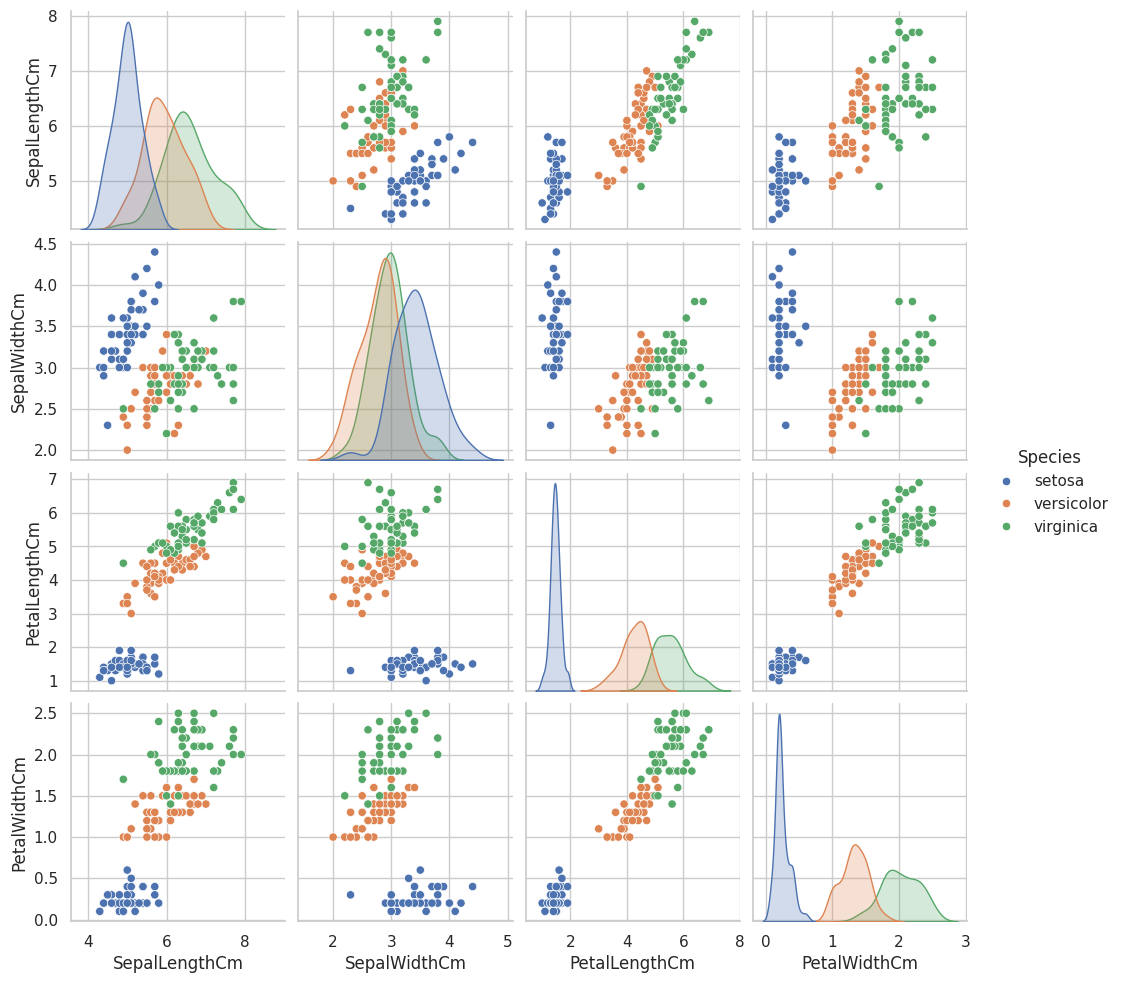

In [13]:
sns.pairplot(df, hue="Species", diag_kind="kde")
plt.show()

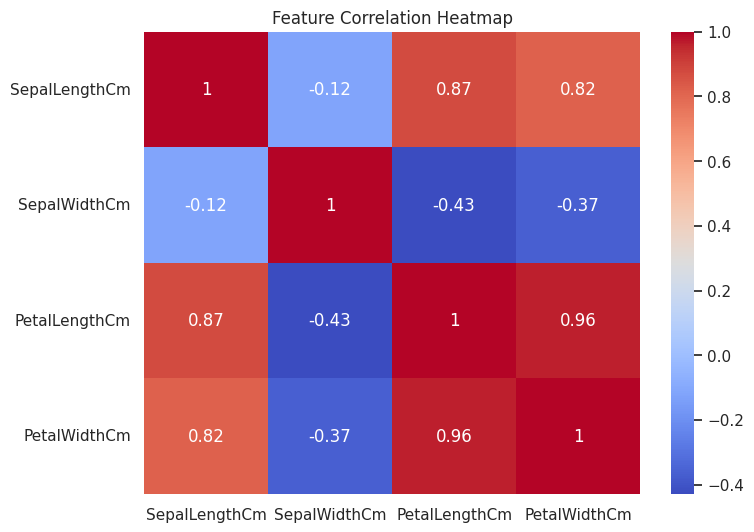

In [14]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns=["Species"]).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

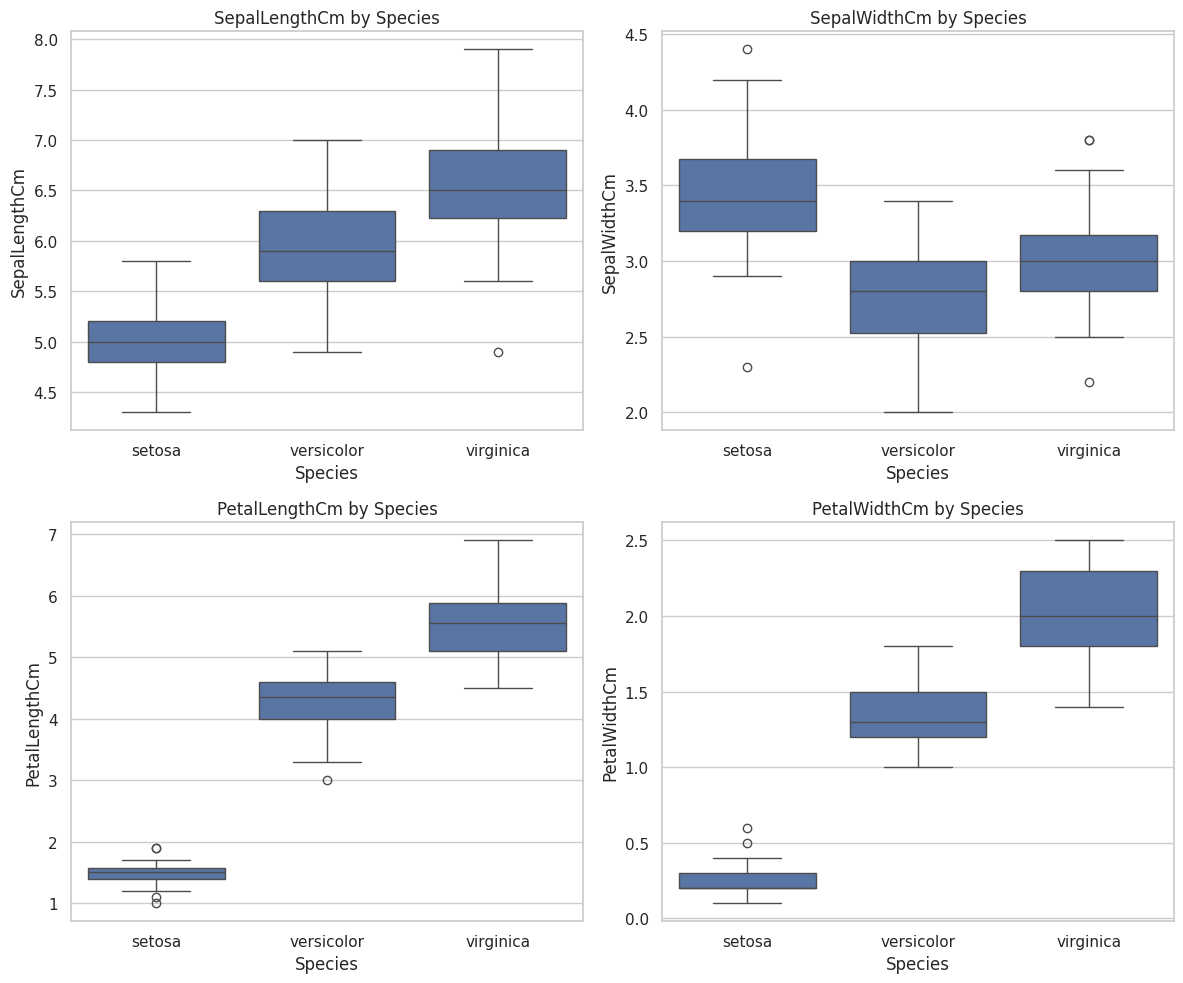

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x="Species", y=feature, ax=ax)
    ax.set_title(f"{feature} by Species")
plt.tight_layout()
plt.show()

## 4. Prepare the Data for Modeling

In [16]:
X = df.drop(columns=["Species"])
y = df["Species"]

# Encode species labels into numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", list(le.classes_))

Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## 5. Train Multiple Models and Compare

In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel="linear", random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

Logistic Regression: Accuracy = 0.9333
K-Nearest Neighbors: Accuracy = 0.9333
Decision Tree: Accuracy = 0.9333
Random Forest: Accuracy = 0.9000
SVM: Accuracy = 1.0000


In [19]:
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy
4,SVM,1.000000
0,Logistic Regression,0.933333
1,K-Nearest Neighbors,0.933333
2,Decision Tree,0.933333
3,Random Forest,0.900000


/tmp/ipykernel_752/498096354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Accuracy", y="Model", palette="viridis")


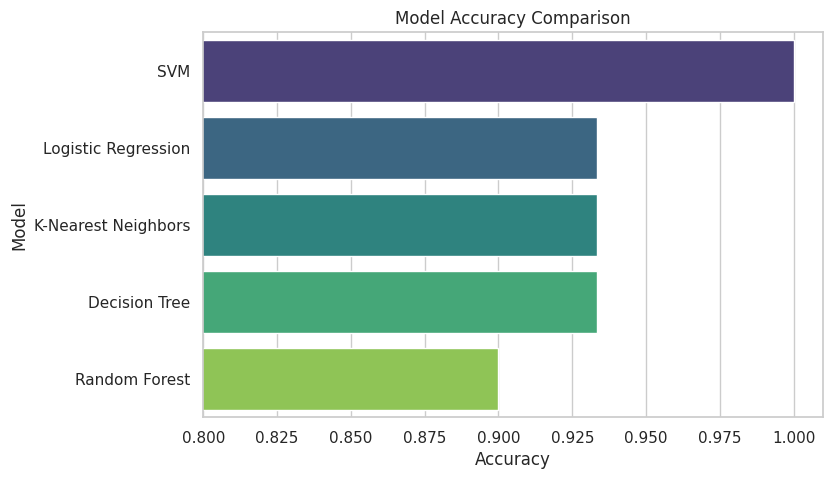

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Accuracy", y="Model", palette="viridis")
plt.xlim(0.8, 1.01)
plt.title("Model Accuracy Comparison")
plt.show()

## 6. Detailed Evaluation of the Best Model

In [21]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print(f"Best Model: {best_model_name}")

y_pred_best = best_model.predict(X_test_scaled)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Best Model: SVM

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



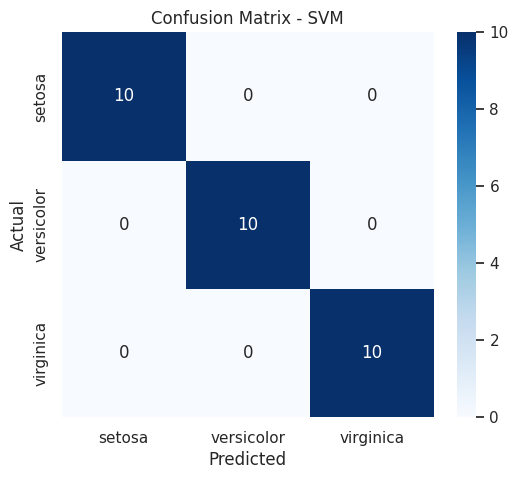

In [22]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## 7. Make Predictions on New Data

In [23]:
# Example: predict species for a new flower measurement
# [SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm]
sample = np.array([[5.1, 3.5, 1.4, 0.2]])
sample_scaled = scaler.transform(sample)

prediction = best_model.predict(sample_scaled)
predicted_species = le.inverse_transform(prediction)

print("Predicted Species:", predicted_species[0])

Predicted Species: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 8. (Optional) Feature Importance - Random Forest

/tmp/ipykernel_752/439224776.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="magma")


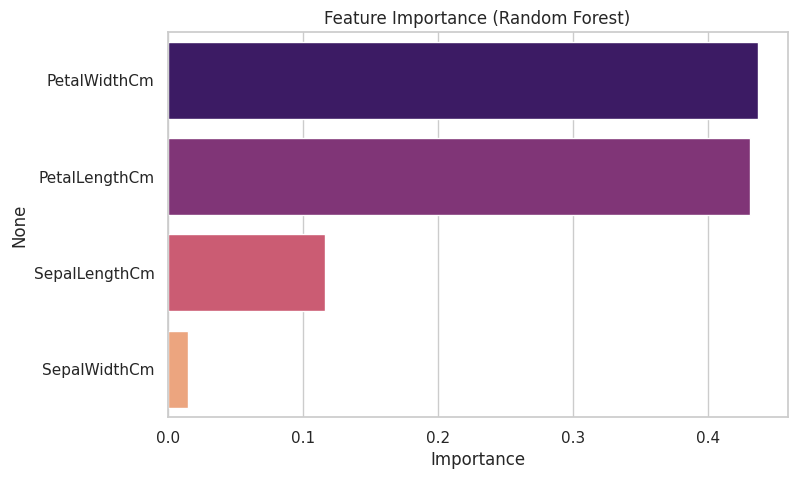

In [24]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette="magma")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

## 9. Conclusion

- We loaded and explored the Iris dataset (3 species: Setosa, Versicolor, Virginica).
- We visualized relationships between sepal/petal measurements and species.
- We trained and compared 5 different ML models.
- The best-performing model achieved high accuracy (typically ~96-100% on this dataset).
- We demonstrated how to use the trained model to classify new flower measurements.